In [45]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import Any

In [46]:
load_dotenv()

subgraph_llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")

In [47]:
class SubState(TypedDict):
    input_text: str
    translated_text: str

In [48]:
def translate_text(state: SubState):
    
    prompt: Any = f"""
        Translate the following text to Hindi.
        Keep it natural and clear. Do not add extra content.
        
        Text: 
        {state['input_text']}
    """.strip()
    
    translated_text = subgraph_llm.invoke(prompt).content
    
    return {'translated_text': translated_text}

In [49]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

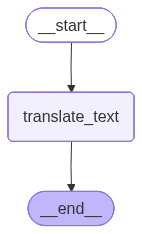

In [50]:
subgraph

In [51]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_hin: str

In [52]:
parent_llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")

In [53]:
def generate_answer(state: ParentState):
    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly. \n\n Question: {state['question']}").content
    
    return {'answer_eng': answer}

In [54]:
def translate_answer(state: ParentState):
    
    # Call subgraph
    sub_input: SubState = {"input_text": state["answer_eng"], "translated_text": ""}
    result = subgraph.invoke(sub_input)
    
    return {'answer_hin': result['translated_text']}

In [55]:
parent_graph = StateGraph(ParentState)

parent_graph.add_node("answer", generate_answer)
parent_graph.add_node("translate", translate_answer)

parent_graph.add_edge(START, 'answer')
parent_graph.add_edge('answer', 'translate')
parent_graph.add_edge('translate', END)

graph = parent_graph.compile()

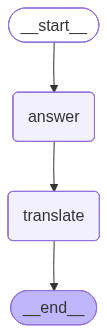

In [56]:
graph

In [57]:
graph.invoke({"question": "What is quant engineering?"})

{'question': 'What is quant engineering?',
 'answer_eng': [{'type': 'text',
   'text': '**Quant engineering** is a multidisciplinary field that sits at the intersection of **finance, mathematics, and computer science.**\n\nAt its core, a quant engineer is responsible for building, testing, and maintaining the complex software systems and algorithmic models that investment banks, hedge funds, and trading firms use to make financial decisions.\n\nHere is a breakdown of what the role entails:\n\n### 1. The Core Objective\nQuant engineers build the "plumbing" and the "engines" for quantitative finance. While "Quant Researchers" (or "Quants") focus on discovering new trading strategies by analyzing data, **Quant Engineers** ensure those strategies can actually be executed in the real world reliably, efficiently, and at scale.\n\n### 2. Key Responsibilities\n*   **Low-Latency Programming:** Many quant strategies rely on speed. Quant engineers write code (often in C++ or FPGA) to execute trad